#Double Pendulum Modelling

This notebook generates a simulated trajectory of a double pendulum using a system of coupled nonlinear ODEs.

The output is used as input data for the machine learning forecasting notebook.

In [25]:
# Preamble :

# Import required libraries :

# Libraries for the mathematics
import numpy as np
from scipy.integrate import solve_ivp

# Libraries for plotting and style
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl

# Set default figure size
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']     = 200

In [26]:
# Initialise parameters for double pendulum system

# Initial Lengths
L1, L2 = 1., 1.

# Inital masses
m1, m2 = 3., 1.

# Initial angles [theta1, omega1, theta2, omega2]
z0 = [np.pi/2,0,np.pi/2,0]

# Define Gravitational acceleration (m/s^2)
g = 9.81

# Define time domain
tmax, dt = 50, 0.1
t = np.arange(0,tmax+dt, dt)


In [27]:
def double_pendulum_ode(t, z, L1, L2, m1, m2, g):
    """
    Computes the time derivatives for the double pendulum system.
    State vector z = [theta1, omega1, theta2, omega2].
    """

    theta1, omega1, theta2, omega2 = z

    # Difference in angular positions
    delta_theta = theta1 - theta2

    # Define variables which store trigonometic functions of theta
    cos_delta =  np.cos(delta_theta)
    sin_delta =  np.sin(delta_theta)
    sin_theta1  =  np.sin(theta1)
    sin_theta2  =  np.sin(theta2)

    # Shared terms in angular acceleration:

    # Gravitational term
    g_term = (m1 + m2) * g * sin_theta1

    # Coupling term
    coupling = m2 * cos_delta * sin_delta

    # common denominator term
    eta = cos_delta**2* m2 - (m1 + m2)


    # Angular accelerations
    d_omega1 = (   L1  * coupling  *  omega1**2 + L2 * m2
                       * sin_delta *  omega2**2
                       - m2 * g    *  cos_delta * sin_theta2
                       + g_term)   /  (L1 * eta)

    d_omega2 = -(  L2 * coupling  * omega2**2 +  L1 * (m1 + m2)
                      * sin_delta * omega1**2 +  g_term
                      * cos_delta - (m1 + m2) *  g *
                      sin_theta2) / (L2 * eta)

            # Output the angluar velocity (omega's)
            # and angular acceleration (omega dot's)

    return omega1, d_omega1, omega2, d_omega2


def to_cartesian(theta1, omega1, theta2, omega2, L1, L2):
    """ Converts the polar coordinates (theta and omega)
        into cartesian coordinates(x,y) and velocities (vx,vy).

        Returns x1, y1, x2, y2, vx1, vy1, vx2, vy2.
    """
    x1 =  L1  * np.sin(theta1)
    y1 = -L1  * np.cos(theta1)

    x2 =  x1  + L2 * np.sin(theta2)
    y2 =  y1  - L2 * np.cos(theta2)

    vx1 = L1  * np.cos(theta1) * omega1
    vy1 = L1  * np.sin(theta1) * omega1

    vx2 = vx1 + L2 * np.cos(theta2) * omega2
    vy2 = vy1 + L2 * np.sin(theta2) * omega2

    return x1, y1, x2, y2, vx1, vy1, vx2, vy2


In [28]:
# Find Solution for double pendulum ODE using initial conditions
ret = solve_ivp(double_pendulum_ode, (0,tmax), z0, t_eval=t, args=(L1, L2, m1, m2, g))

# Retrive solution arrays and store in state vector, Z
z = ret.y

# Check dimensions of state vector Z is in form (4,N) ;
# where N is the number of time steps
print(np.shape(z))

# Assign each state variable from the state vector Z
theta1, omega1, theta2, omega2 = z[0], z[1], z[2], z[3]

# Generate Cartesian trajectories from angular data
x1, y1, x2, y2, vx1, vy1, vx2, vy2 = to_cartesian(theta1, omega1, theta2, omega2, L1, L2)

(4, 501)


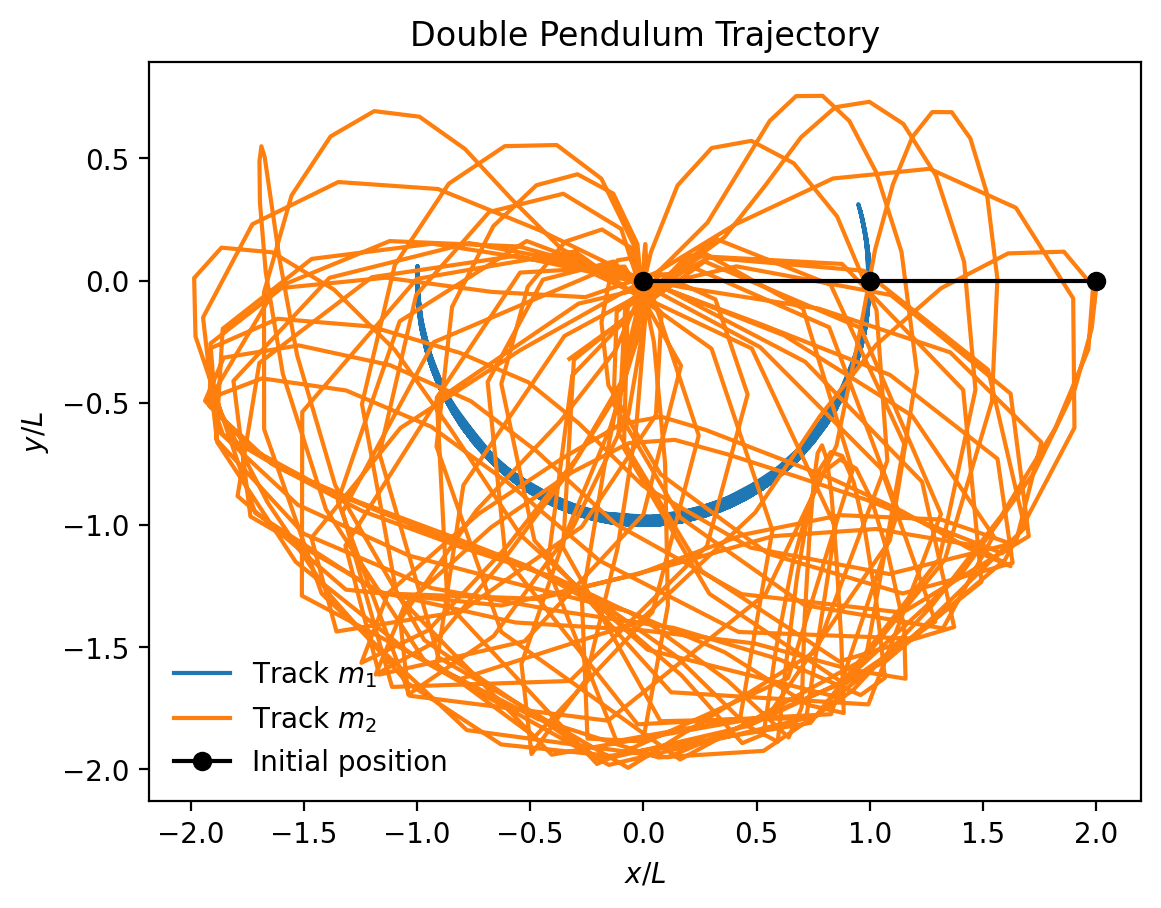

In [29]:
# Plot the trajectories of both masses
fig,ax=plt.subplots()
ax.plot(x1, y1, label=r"Track $m_1$")
ax.plot(x2, y2, label=r"Track $m_2$")

# Initial configuration
ax.plot([0, x1[0], x2[0]], [0, y1[0], y2[0]], "-o", label="Initial position", c='k')

# Label the plot
ax.set_title("Double Pendulum Trajectory")
plt.ylabel(r"$y/L$")
plt.xlabel(r"$x/L$")
ax.legend()